# Streamgauge network design for Texas-Gulf Region (HUC2: 12)

This notebook:
1. Downloads USGS gauge network data (with skip-if-exists)
2. Downloads NWM streamflow data for Texas-Gulf region (with skip-if-exists)
3. Matches USGS gauges to NWM COMIDs
4. Designs optimal sensor network
5. Compares optimal vs USGS network performance
6. Visualizes ΔNNSE improvements

In [1]:
from hydrosensenet.data import (
    NWMDataLoader, get_huc_info, list_available_hucs,
    download_usgs_gauges, load_usgs_gauges, match_usgs_to_nwm
)
from hydrosensenet.io import save_streamflow, load_streamflow
from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# Configuration
HUC2 = "12"  # Texas-Gulf Region
YEARS = list(range(2000, 2010))  # 2000-2009 (10 years)
OUTPUT_DIR = Path("./data/texas_gulf")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Configuration:")
print(f"  Region: HUC2 {HUC2}")
print(f"  Years: {YEARS[0]}-{YEARS[-1]} ({len(YEARS)} years)")
print(f"  Output: {OUTPUT_DIR}")

Configuration:
  Region: HUC2 12
  Years: 2000-2009 (10 years)
  Output: data\texas_gulf


## Step 1: Download USGS Gauge Network

Download USGS gauge locations for baseline comparison.

In [2]:
# Download USGS gauge network (skips if exists)
# Downloads all CONUS gauges, then filters by matching to NWM COMIDs
# Returns: (geojson_file, comid_linkage_file)
usgs_geojson_file, usgs_comid_file = download_usgs_gauges(
    output_dir=OUTPUT_DIR,
    huc2=None,  # Download all CONUS gauges (filtering happens later via COMID matching)
    force_download=False,  # Set to True to re-download
    verbose=True
)

# Load USGS gauges and COMID linkage
usgs_gauges, comid_linkage = load_usgs_gauges(
    shapefile_path=usgs_geojson_file,
    comid_linkage_path=usgs_comid_file
)

print(f"\n✓ USGS gauges loaded: {len(usgs_gauges):,} stations")
print(f"✓ COMID linkage loaded: {len(comid_linkage):,} gauge-COMID pairs")
print(f"\nFirst 5 gauges:")
print(usgs_gauges.head())

✓ USGS gauge data already exists:
  Locations: data\texas_gulf\usgs_gauges_all.geojson
  COMID linkage: data\texas_gulf\usgs_comid_linkage_all.csv
  13,248 gauges loaded

✓ USGS gauges loaded: 13,248 stations
✓ COMID linkage loaded: 12,422 gauge-COMID pairs

First 5 gauges:
    Gage_no                            Gage_name   Gage_type   Lat_nwis  \
0  01098530      SUDBURY RIVER AT SAXONVILLE, MA    ContGage  42.325373   
1  01122680          MERRICK BK NR SCOTLAND, CT.  CrestStage  41.728988   
2  01176000  QUABOAG RIVER AT WEST BRIMFIELD, MA    ContGage  42.182316   
3  01173500     WARE RIVER AT GIBBS CROSSING, MA    ContGage  42.236204   
4  01127500           YANTIC RIVER AT YANTIC, CT    ContGage  41.558709   

   Long_nwis   SqKm_nwis   Lat_snap  Long_snap    COMID  COMID_meas  ... Pass  \
0 -71.397560  274.538739  42.325326 -71.397449  6772927   81.239789  ...    1   
1 -72.085076   13.493838  41.728987 -72.084926  6162963    4.732031  ...    1   
2 -72.263691  388.498215  42.18

## Step 2: Initialize NWM Data Loader

Check for existing COMIDs file before querying NHDPlus.

In [3]:
# Initialize Dask-optimized loader
loader = NWMDataLoader(
    version="3.0",
    use_dask=True,
    n_workers=6,
    threads_per_worker=4,
    memory_limit='2GB'
)
print("✓ NWM Data Loader initialized (v3.0)")

✓ Dask cluster started: http://127.0.0.1:8787/status
  Workers: 6, Threads/worker: 4, Memory/worker: 2GB
✓ NWM Data Loader initialized (v3.0)


## Step 3: Filter by HUC2 Region

Get COMIDs for Texas-Gulf region.

In [4]:
# Filter by HUC2 level 12 (entire Texas-Gulf)
loader.filter_by_huc(HUC2, huc_level=2)

print(f"\n✓ Filtering complete!")
print(f"  Total COMIDs found: {len(loader.comids):,}")
print(f"\nFirst 10 COMIDs: {loader.comids[:10]}")

Fetching COMIDs for HUC2: 12...
  Filtering 2,691,339 flowlines by HUC2...

✓ Found 68,892 NHDPlusV2 COMIDs in HUC 12
  These COMIDs match NWM v3.0 feature_id values

✓ Filtering complete!
  Total COMIDs found: 68,892

First 10 COMIDs: [5256719, 5256717, 5256841, 5256297, 5256933, 5256391, 5256425, 5256459, 5256551, 5256973]


## Step 4: Download Flowlines Geometry (Skip if Exists)

In [5]:
# Check if flowlines already exist
flowlines_file = OUTPUT_DIR / "texas_gulf_flowlines_full.geojson"

if flowlines_file.exists():
    print(f"✓ Flowlines already exist: {flowlines_file}")
    flowlines_gdf = gpd.read_file(flowlines_file)
    print(f"  Loaded {len(flowlines_gdf):,} flowlines")
else:
    print("Downloading flowlines...")
    flowlines_file = loader.export_locations(
        output_file=flowlines_file,
        format="geojson",
        use_full_geometries=True
    )
    flowlines_gdf = gpd.read_file(flowlines_file)
    print(f"✓ Downloaded {len(flowlines_gdf):,} flowlines")

✓ Flowlines already exist: data\texas_gulf\texas_gulf_flowlines_full.geojson
  Loaded 68,892 flowlines


## Step 5: Download Streamflow Data (Skip Existing Years)

In [6]:
# Check which years already exist
existing_files = []
missing_years = []

for year in YEARS:
    file_path = OUTPUT_DIR / f"streamflow_{year}.parquet"
    if file_path.exists():
        existing_files.append(file_path)
    else:
        missing_years.append(year)

print(f"Existing data: {len(existing_files)}/{len(YEARS)} years")
print(f"Missing years: {missing_years if missing_years else 'None'}")

# Download only missing years
if missing_years:
    print(f"\nDownloading {len(missing_years)} missing years...")
    print(f"Estimated time: {len(missing_years) * 10}-{len(missing_years) * 15} minutes\n")
    
    new_files = loader.download_multiple_years(
        years=missing_years,
        output_dir=OUTPUT_DIR,
        resample="D",
        resample_method="mean",
        batch_size=10000,
        format="parquet"
    )
    
    all_files = sorted(existing_files + new_files)
    print(f"\n✓ Download complete! Total: {len(all_files)} years")
else:
    all_files = sorted(existing_files)
    print(f"\n✓ All years already downloaded!")

Existing data: 10/10 years
Missing years: None

✓ All years already downloaded!


## Step 6: Load Combined Data for Analysis

In [7]:
from hydrosensenet import SensorNetworkDesigner

print(f"Loading {len(all_files)} years of cleaned data...")

# Load and concatenate all years
dfs = []
for file in all_files:
    df = load_streamflow(file)
    dfs.append(df)
    print(f"  Loaded {file.name}: {df.shape}")

streamflow_combined = pd.concat(dfs, axis=0).sort_index()
print(f"\n✓ Combined streamflow: {streamflow_combined.shape}")

# Get COMIDs that exist in streamflow data
available_comids = [int(col) for col in streamflow_combined.columns]
print(f"  Available COMIDs: {len(available_comids):,}")

# Filter flowlines to match streamflow COMIDs
locations_gdf_filtered = flowlines_gdf[flowlines_gdf['comid'].isin(available_comids)].copy()
print(f"\n  Filtered locations: {len(locations_gdf_filtered):,}")

# Convert to numpy array for faster processing
streamflow_matrix = streamflow_combined.values
location_labels = [str(c) for c in streamflow_combined.columns]

# Initialize designer
designer = SensorNetworkDesigner(
    streamflow_data=streamflow_matrix,
    locations=locations_gdf_filtered,
    location_labels=location_labels
)

print(f"\n✓ Designer initialized!")
print(f"  Streamflow: {designer.streamflow_data.shape} ({YEARS[0]}-{YEARS[-1]})")
print(f"  Locations: {len(designer.locations):,} COMIDs")

Loading 10 years of cleaned data...
  Loaded streamflow_2000.parquet: (366, 64954)
  Loaded streamflow_2001.parquet: (365, 64954)
  Loaded streamflow_2002.parquet: (365, 64954)
  Loaded streamflow_2003.parquet: (365, 64954)
  Loaded streamflow_2004.parquet: (366, 64954)
  Loaded streamflow_2005.parquet: (365, 64954)
  Loaded streamflow_2006.parquet: (365, 64954)
  Loaded streamflow_2007.parquet: (365, 64954)
  Loaded streamflow_2008.parquet: (366, 64954)
  Loaded streamflow_2009.parquet: (365, 64954)

✓ Combined streamflow: (3653, 64954)
  Available COMIDs: 64,954

  Filtered locations: 64,954

✓ Designer initialized!
  Streamflow: (3653, 64954) (2000-2009)
  Locations: 64,954 COMIDs


## Step 7: Match USGS Gauges to NWM COMIDs

In [8]:
# Match USGS gauges to NWM COMIDs using the helper function
usgs_comids, matched_usgs_gdf = match_usgs_to_nwm(
    usgs_gdf=usgs_gauges,
    comid_linkage=comid_linkage,
    available_comids=location_labels,
    verbose=True
)

# Get indices for USGS gauge locations in the designer's data
if len(usgs_comids) > 0:
    usgs_indices = [location_labels.index(str(comid)) for comid in usgs_comids]
    print(f"\n✓ USGS gauge indices in NWM dataset: {len(usgs_indices)}")
    print(f"  Example indices: {usgs_indices[:5]}...")
    print(f"  Example COMIDs: {usgs_comids[:5]}...")
else:
    print("\n⚠ No USGS gauges matched to NWM data")
    print("This may mean:")
    print("  1. COMID linkage file is empty (check download warnings)")
    print("  2. No overlap between USGS gauges and your NWM COMIDs")
    print("  3. GAGES-II basin characteristics couldn't be downloaded")
    usgs_indices = []

✓ Matched 455 USGS gauges to NWM COMIDs
  Example COMIDs: [3585554, 1438379, 3168874, 1440525, 1520249]...

✓ USGS gauge indices in NWM dataset: 455
  Example indices: [50502, 19068, 57818, 19479, 21952]...
  Example COMIDs: [3585554, 1438379, 3168874, 1440525, 1520249]...


## Step 8: Design Optimal Network and Compare to USGS

In [9]:
# Design optimal sensor network
print("Designing optimal sensor network...\n")

n_sensors = len(usgs_indices) if usgs_indices else 400

optimal_result = designer.design_network(
    n_sensors=n_sensors,
    evaluate=True,
    verbose=True
)

print("\n" + "="*70)
optimal_result.print_summary()
print("="*70)

Designing optimal sensor network...


SENSOR NETWORK DESIGN
Input data: 3,653 timesteps × 64,954 locations
Target sensors: 455
Evaluation: Enabled

[2/4] Splitting data (train: 70%, test: 30%)...
      ✓ Train: 2,557 × 64,954
      ✓ Test:  1,096 × 64,954
      Completed in 2.43s

[3/4] Running QR decomposition for sensor placement...
      Matrix size: 2,557 × 64,954
      This may take several minutes for large datasets...
      - Converting to Fortran order for LAPACK...
      - Running pivoted QR decomposition...
      ✓ QR decomposition completed in 112.83s
      ✓ Selected 455 sensor locations

[4/4] Evaluating reconstruction performance...
      - Extracting data for 455 selected sensors...
      - Computing Gram matrix (455 × 455)...
      - Solving linear system for reconstruction...
      - Reconstructing full field (1,096 × 64,954)...
      - Calculating error metrics...
      ✓ Evaluation completed in 9.06s
      Relative error: 0.0371

DESIGN COMPLETE



SENSOR NETWORK DES

In [10]:
# Evaluate USGS network if we have matched gauges
if usgs_indices:
    print(f"\nEvaluating USGS gauge network ({len(usgs_indices)} gauges)...\n")
    
    usgs_result = designer.design_network(
        n_sensors=len(usgs_indices),
        existing_sensors=usgs_indices,  # Force use of USGS locations
        evaluate=True,
        verbose=True
    )
    
    print("\n" + "="*70)
    usgs_result.print_summary()
    print("="*70)


Evaluating USGS gauge network (455 gauges)...


SENSOR NETWORK DESIGN
Input data: 3,653 timesteps × 64,954 locations
Target sensors: 455
Evaluation: Enabled

[2/4] Splitting data (train: 70%, test: 30%)...
      ✓ Train: 2,557 × 64,954
      ✓ Test:  1,096 × 64,954
      Completed in 1.48s

[3/4] Using 455 existing sensor locations (skipping QR)...

[4/4] Evaluating reconstruction performance...
      - Extracting data for 455 selected sensors...
      - Computing Gram matrix (455 × 455)...
      - Solving linear system for reconstruction...
      ⚠ Warning: Gram matrix is rank-deficient (rank=447, expected=455)
        This suggests some sensors provide redundant information.
      - Reconstructing full field (1,096 × 64,954)...
      - Calculating error metrics...
      ✓ Evaluation completed in 8.58s
      Relative error: 0.2335

DESIGN COMPLETE



SENSOR NETWORK DESIGN RESULTS
Number of sensors selected: 455
Selected locations: [50502 19068 57818 19479 21952 53014 29446 56397 2193

## Step 9: Visualize Comparison

Figure saved to: data\texas_gulf\sensor_comparison_usgs.png


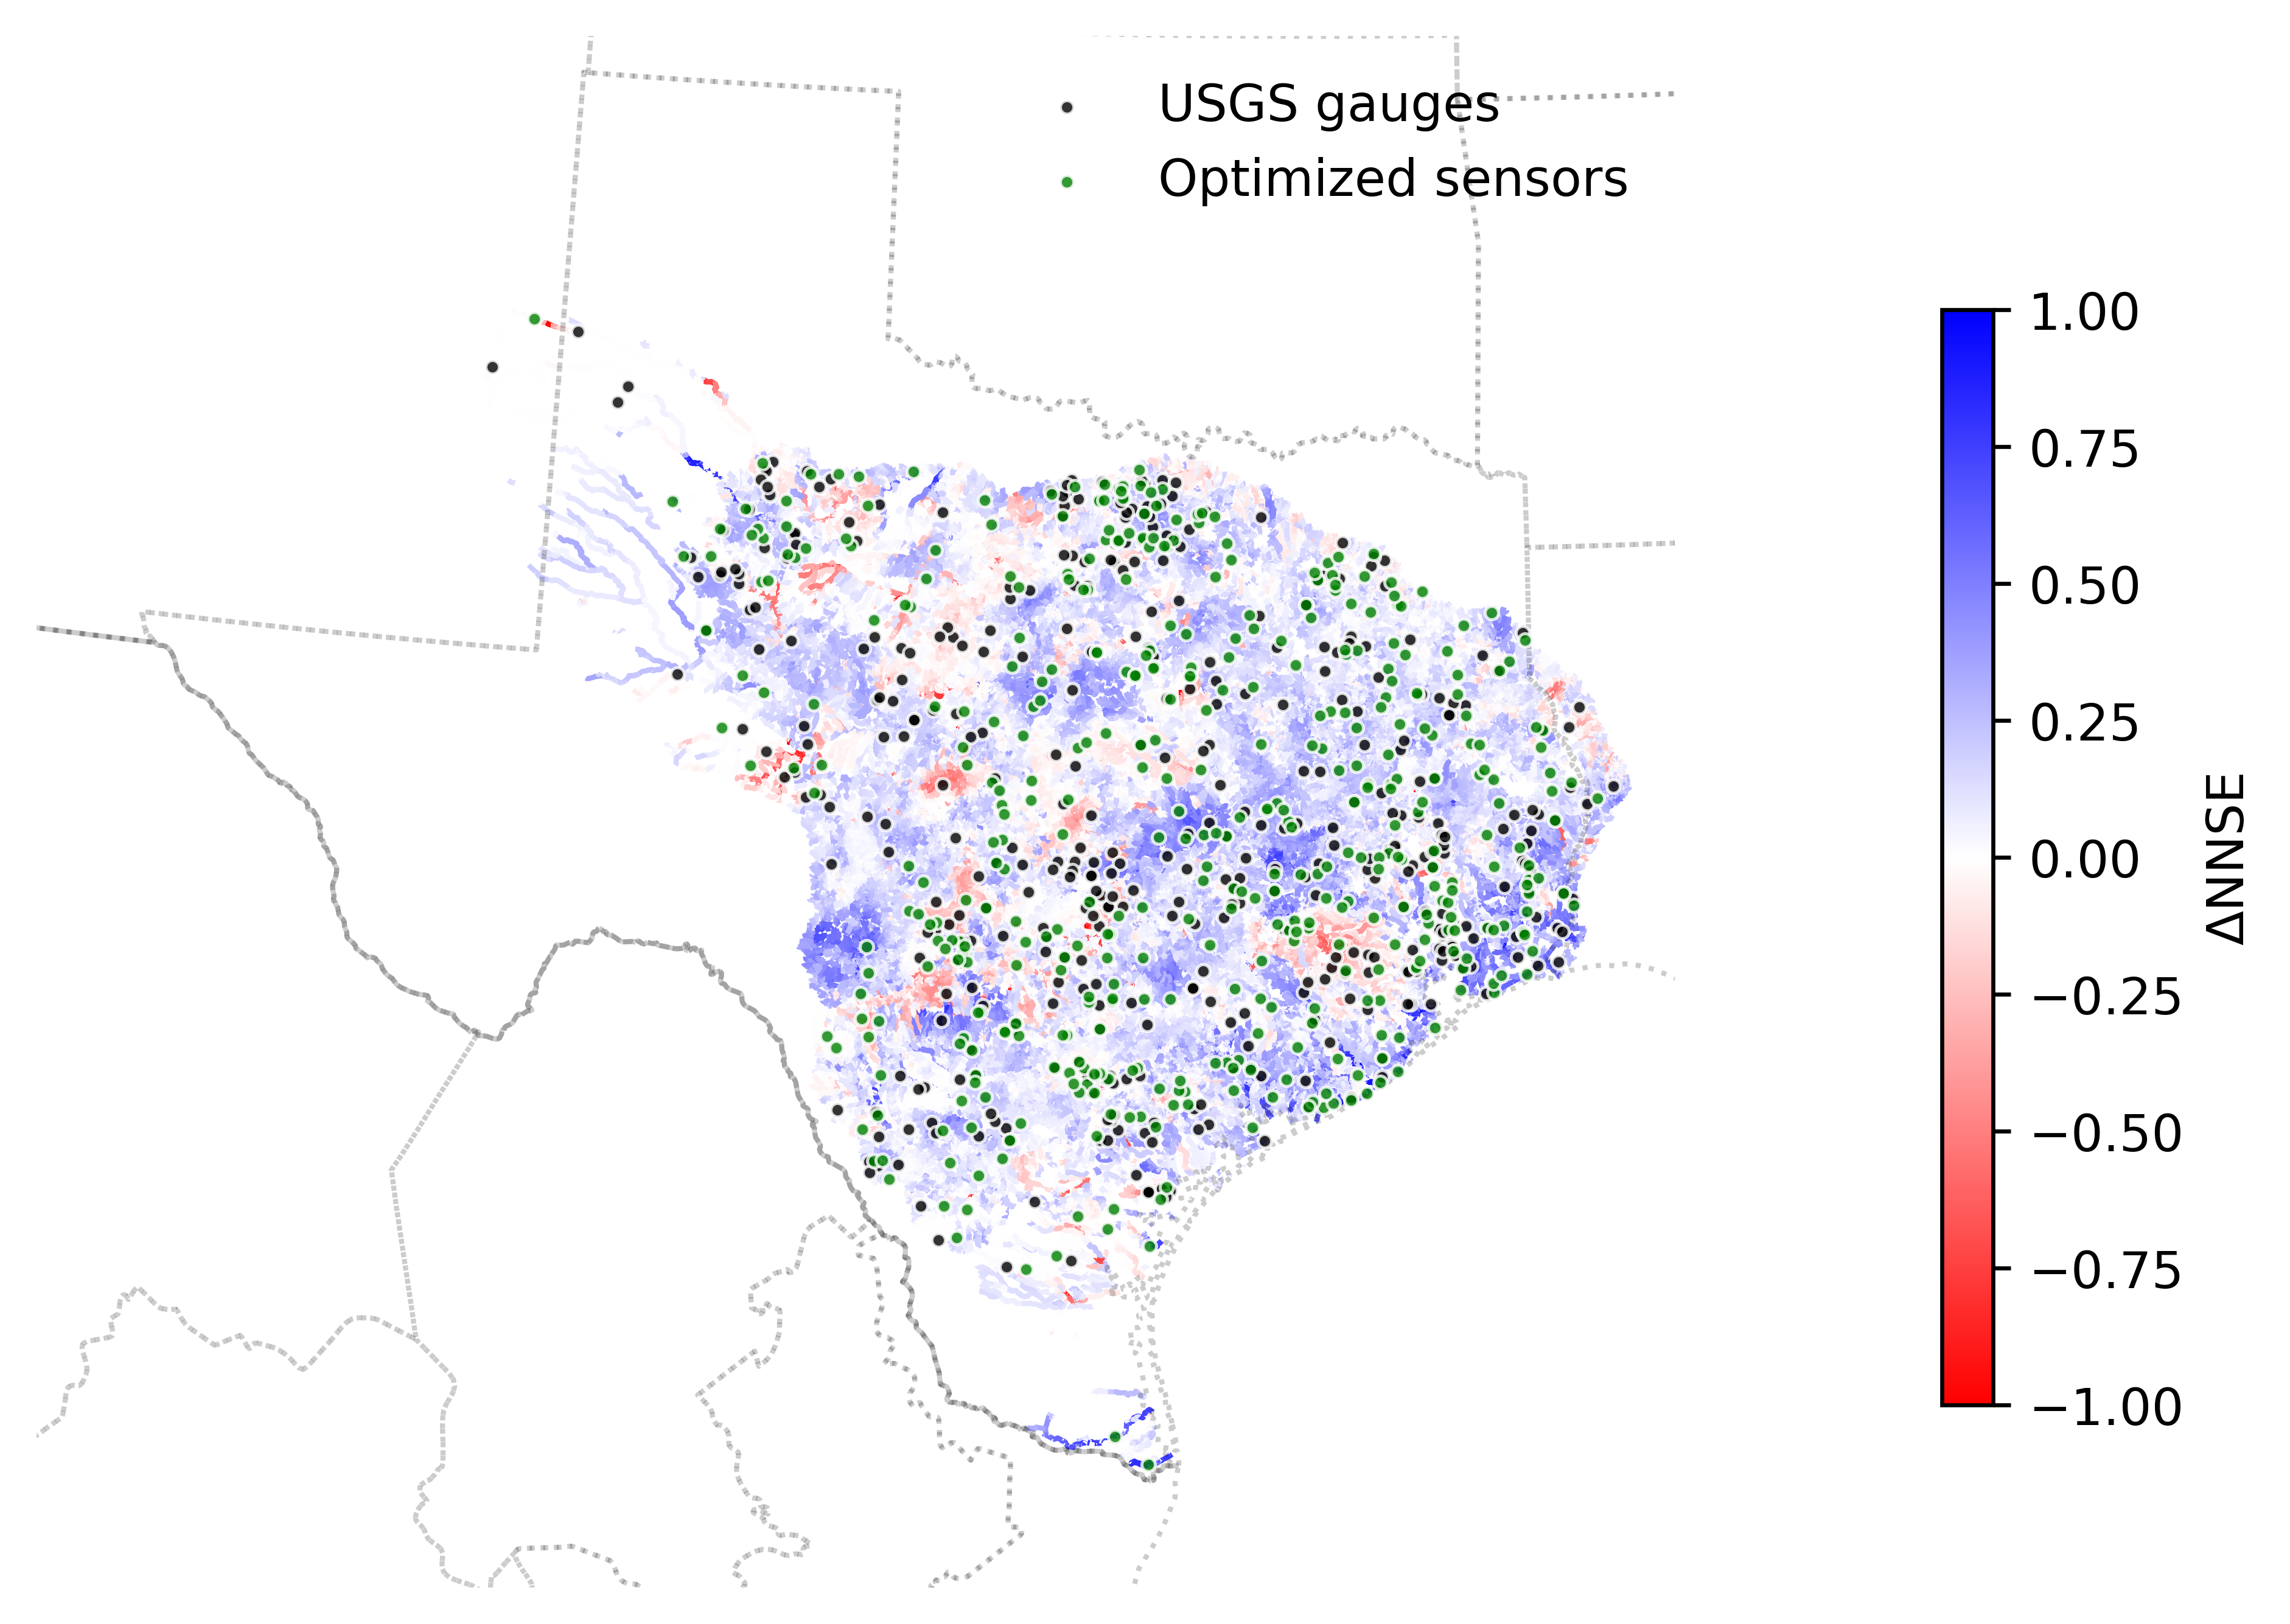


Performance Improvement Statistics:
  Mean ΔNNSE: 0.1140
  Median ΔNNSE: 0.0994
  Locations improved: 49,458 / 64,954 (76.1%)


2026-01-09 00:27:39,940 - distributed.nanny - WARNING - Restarting worker
2026-01-09 00:27:39,950 - distributed.nanny - WARNING - Restarting worker
2026-01-09 00:27:39,958 - distributed.nanny - WARNING - Restarting worker
2026-01-09 00:27:40,011 - distributed.nanny - WARNING - Restarting worker
2026-01-09 00:27:40,030 - distributed.nanny - WARNING - Restarting worker
2026-01-09 03:05:32,406 - distributed.nanny - WARNING - Restarting worker
2026-01-09 03:05:32,411 - distributed.nanny - WARNING - Restarting worker
2026-01-09 03:05:32,416 - distributed.nanny - WARNING - Restarting worker
2026-01-09 03:05:32,422 - distributed.nanny - WARNING - Restarting worker
2026-01-09 03:05:32,429 - distributed.nanny - WARNING - Restarting worker


In [ ]:
if usgs_indices:
    # Plot comparison showing ΔNNSE
    fig, ax = optimal_result.plot_comparison(
        baseline_result=usgs_result,
        flowlines_gdf=flowlines_gdf,
        location_labels=location_labels,
        comparison_labels={
            'optimal': 'Optimized sensors',
            'baseline': 'USGS gauges'
        },
        metric='nnse',
        figsize=(7, 5),
        save_path=OUTPUT_DIR / "sensor_comparison_usgs.png"
    )
    
    plt.show()
    
    # Calculate improvement statistics
    optimal_nnse = optimal_result.performance_metrics['nnse']
    usgs_nnse = usgs_result.performance_metrics['nnse']
    improvement = optimal_nnse - usgs_nnse
    
    print(f"\nPerformance Improvement Statistics:")
    print(f"  Mean ΔNNSE: {np.nanmean(improvement):.4f}")
    print(f"  Median ΔNNSE: {np.nanmedian(improvement):.4f}")
    print(f"  Locations improved: {(improvement > 0).sum():,} / {len(improvement):,} ({100*(improvement > 0).sum()/len(improvement):.1f}%)")
else:
    print("Skipping comparison plot - no matched USGS gauges")